In [59]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
%matplotlib inline
import numpy as np

#minmaxscaler use case:
"""
In machine learning, MinMaxScaler is a feature scaling technique used to
normalize numerical data by shrinking it into a specific, bounded range—most 
commonly [0, 1]. It is a critical preprocessing step that ensures features with
different units or magnitudes (e.g., age vs. annual income) contribute equally 
to the model."""

#normalization
"""
Data normalization in machine learning scales features to a common 
range (like 0 to 1) so they have equal influence, preventing large-valued 
features from dominating, improving algorithm performance, speeding up 
training, and ensuring stability, especially for models like neural networks 
or KNN, using techniques like Min-Max Scaling or Z-score standardization"""

'\nData normalization in machine learning scales features to a common \nrange (like 0 to 1) so they have equal influence, preventing large-valued \nfeatures from dominating, improving algorithm performance, speeding up \ntraining, and ensuring stability, especially for models like neural networks \nor KNN, using techniques like Min-Max Scaling or Z-score standardization'

-->To find the new value for any salary, use this simple calculation by 
using MinMaxScaler:
 new value = (currrent salary - minimumsalary) / (maximum salary - miminum salary)
For example: a = 40000, b = 60000, c = 80000, d = 100000
->BY USING MinMaxScaler we can get values of highest as 1 and lowest as 0 
and values between them as decimal values
here: 
a is 0(minimum) and d is 1(maximum). by 
using MinMaxScaler: we get b as 0.33, c as 0.66

In [14]:
df = pd.read_csv("income.csv")
df


,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautam,39,155000
6,David,41,160000
7,Andrea,38,162000
8,Brad,36,156000
9,Angelina,35,130000


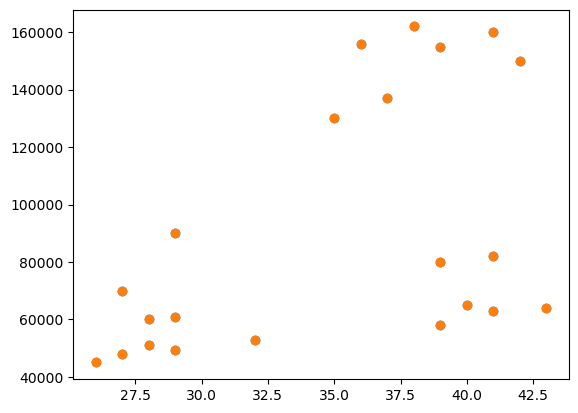

In [8]:
plt.scatter(df['Age'], df['Income($)'])
plt.show()

In [19]:
km = KMeans(n_clusters = 3)
km

KMeans(n_clusters=3)

In [20]:
y_pred = km.fit_predict(df[['Age', 'Income($)']])
y_pred

C:\Users\nandi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 0, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2],
      dtype=int32)

In [21]:
df['cluster'] = y_pred
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,0
1,Michael,29,90000,0
2,Mohan,29,61000,2
3,Ismail,28,60000,2
4,Kory,42,150000,1


C:\Users\nandi\AppData\Local\Temp\ipykernel_7256\3310752041.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


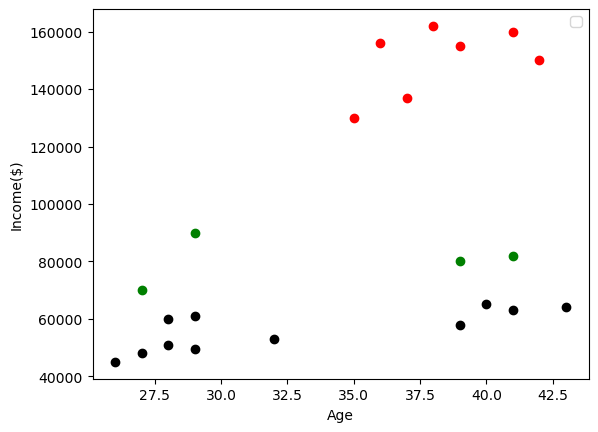

In [22]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]
plt.scatter(df1.Age, df1['Income($)'], color = 'green')
plt.scatter(df2.Age, df2['Income($)'], color = 'red')
plt.scatter(df3.Age, df3['Income($)'], color = 'black')

plt.xlabel('Age')
plt.ylabel('Income($)')
plt.legend()
plt.show()

In [29]:
scaler = MinMaxScaler()
"""If Income is in thousands and Age is in tens, income shouts while age whispers.
Scaling makes them speak at the same volume"""
#scaler.fit(df[['Income($)']])
df[['Income($)']] = scaler.fit_transform(df[['Income($)']])
#scaler.fit(df['Age'])
df[['Age']] = scaler.fit_transform(df[['Age']])
df

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,2
3,Ismail,0.117647,0.128205,2
4,Kory,0.941176,0.897436,1
5,Gautam,0.764706,0.940171,1
6,David,0.882353,0.982906,1
7,Andrea,0.705882,1.000000,1
8,Brad,0.588235,0.948718,1
9,Angelina,0.529412,0.726496,1


In [35]:
km = KMeans(n_clusters = 3)
y_pred = km.fit_predict(df[['Age', 'Income($)']])
y_pred

C:\Users\nandi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [36]:
df['cluster'] = y_pred
df

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1
5,Gautam,0.764706,0.940171,1
6,David,0.882353,0.982906,1
7,Andrea,0.705882,1.000000,1
8,Brad,0.588235,0.948718,1
9,Angelina,0.529412,0.726496,1


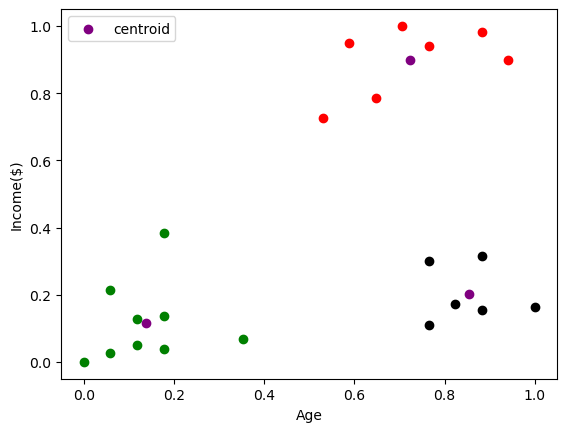

In [57]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]
plt.scatter(df1.Age, df1['Income($)'], color = 'green')
plt.scatter(df2.Age, df2['Income($)'], color = 'red')
plt.scatter(df3.Age, df3['Income($)'], color = 'black')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], color = 'purple', 
            label = 'centroid')
plt.xlabel('Age')
plt.ylabel('Income($)')
plt.legend()
plt.show()

In [46]:
td = km.cluster_centers_
td

array([[0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ],
       [0.85294118, 0.2022792 ]])

In [53]:
"""plt.scatter(td[:, 0], td[:, 1])
plt.show()"""
print(td[:, 0])
print(td[:, 1])


[0.1372549  0.72268908 0.85294118]
[0.11633428 0.8974359  0.2022792 ]


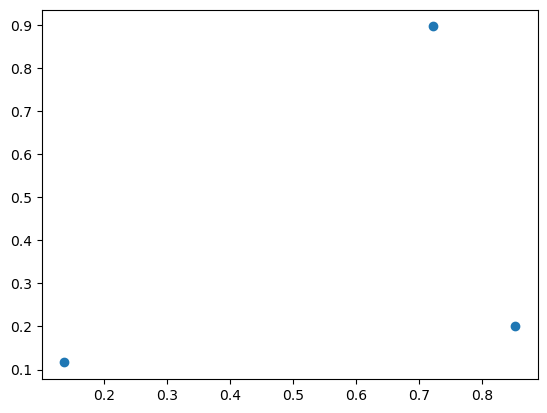

In [56]:
#cluster points are given below

plt.scatter(td[:, 0], td[:, 1])
plt.show()

In [61]:
scaler = MinMaxScaler()
df[['Age', 'Income($)']] = scaler.fit_transform(df[['Age', 'Income($)']])

In [62]:
km.fit(df[['Age', 'Income($)']])

C:\Users\nandi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3)

In [66]:
new = np.array([[27, 100000]])
sc = scaler.transform(new)
y_pred = km.predict (sc)
y_pred

C:\Users\nandi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\nandi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([0], dtype=int32)

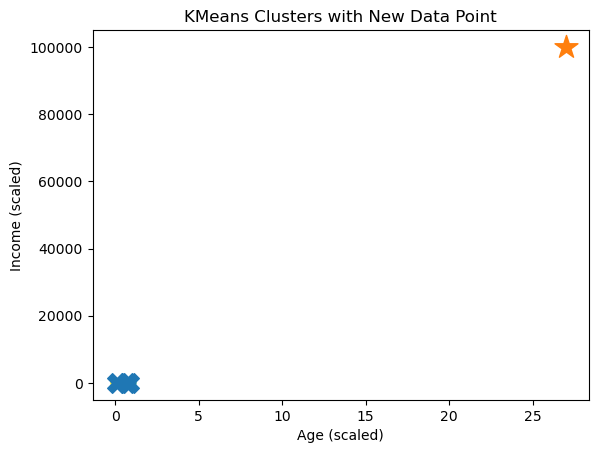

In [67]:
plt.scatter(df['Age'], df['Income($)'], c=km.labels_)

# plot cluster centers
centers = km.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=200)

# plot new data point
plt.scatter(sc[0, 0], sc[0, 1], marker='*', s=300)

plt.xlabel("Age (scaled)")
plt.ylabel("Income (scaled)")
plt.title("KMeans Clusters with New Data Point")

plt.show()
